Import the libraries.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Read the dataset.

In [5]:
df = pd.read_csv("Datasets/fashion-mnist.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Show one data as 28x28 pixel format.

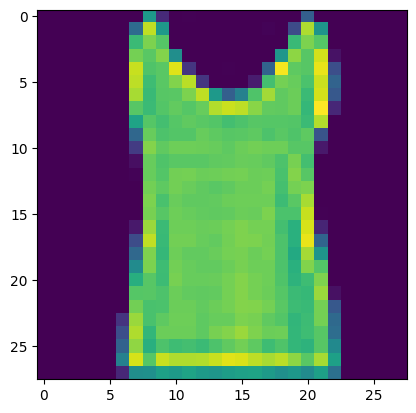

In [6]:
plt.imshow(df.iloc[13050,1:].values.reshape(28,28))

Train test split.

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df.iloc[:,1:], df.iloc[:,0], test_size=0.2, random_state=42)

In [8]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((56000, 784), (14000, 784), (56000,), (14000,))

Applying KNN on data.

In [9]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Time taken by knn model to predict.

In [10]:
import time
start = time.time()
y_pred = knn.predict(x_test)
print(time.time() - start)

20.190871477127075


Accuracy score.

In [11]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8572857142857143

Scale the data.

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

PCA on data.

In [13]:
from sklearn.decomposition import PCA
pca = PCA(n_components=200)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

In [14]:
x_test_pca.shape, x_train_pca.shape

((14000, 200), (56000, 200))

Fit the PCA transformed data.

In [15]:
knn.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Accuracy score.

In [16]:
y_pred = knn.predict(x_test)
accuracy_score(y_test, y_pred)

0.8572857142857143

Scale the data again.

In [17]:
x_train_scaled2 = scaler.fit_transform(x_train)
x_test_scaled2 = scaler.transform(x_test)

In [18]:
x_train_scaled2.shape, x_test_scaled2.shape

((56000, 784), (14000, 784))

Find the best number of parameters for which the model perform best.

In [19]:
for i in range(1, 10): # 785 To go though all components.
    pca = PCA(n_components=i)
    x_train_pca = pca.fit_transform(x_train_scaled2)
    x_test_pca = pca.transform(x_test_scaled2)
    knn.fit(x_train_pca, y_train)
    y_pred = knn.predict(x_test_pca)
    print(f"Accuracy with {i} components: {accuracy_score(y_test, y_pred)}")

Accuracy with 1 components: 0.24442857142857144
Accuracy with 2 components: 0.5040714285714286
Accuracy with 3 components: 0.6183571428571428
Accuracy with 4 components: 0.7024285714285714
Accuracy with 5 components: 0.7432142857142857
Accuracy with 6 components: 0.7685
Accuracy with 7 components: 0.7871428571428571
Accuracy with 8 components: 0.7920714285714285
Accuracy with 9 components: 0.7990714285714285


PCA transforming the data into 2D.

In [20]:
pca_2D = PCA(n_components=2)
x_train_pca_2D = pca_2D.fit_transform(x_train_scaled2)
x_test_pca_2D = pca_2D.transform(x_test_scaled2)
x_train_pca_2D.shape, x_test_pca_2D.shape

((56000, 2), (14000, 2))

Plotting the 2D transformed data.

In [21]:
import plotly.express as px
y_train_str = y_train.astype(str)
fig = px.scatter(x=x_train_pca_2D[:,0], y=x_train_pca_2D[:,1], color=y_train_str, color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

PCA transforming the data into 3D.

In [22]:
pca_3D = PCA(n_components=3)
x_train_pca_3D = pca_3D.fit_transform(x_train_scaled2)
x_test_pca_3D = pca_3D.transform(x_test_scaled2)
x_train_pca_3D.shape, x_test_pca_3D.shape

((56000, 3), (14000, 3))

Plotting the 3D transformed data.

In [23]:
y_train_str = y_train.astype(str)
fig = px.scatter_3d(x=x_train_pca_3D[:,0], y=x_train_pca_3D[:,1], z=x_train_pca_3D[:,2], color=y_train_str, color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

Variance covered by each component.

In [24]:
pca_3D.explained_variance_

array([172.65242169, 113.28629297,  42.85033264])

In [25]:
pca.components_.shape

(9, 784)

Percentage (ratio) variance.

In [26]:
pca_3D.explained_variance_ratio_

array([0.22021599, 0.14449524, 0.05465506])

In [27]:
pca = PCA(n_components=None)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

In [28]:
pca.explained_variance_.shape, pca.components_.shape

((784,), (784, 784))

Cumulative sum of variance ratio of each component.

In [29]:
np.cumsum(pca.explained_variance_ratio_)

array([0.28965526, 0.46773937, 0.52793609, 0.57733441, 0.6156727 ,
       0.65037293, 0.67389095, 0.69290799, 0.70643316, 0.71950555,
       0.7294514 , 0.73862585, 0.74628769, 0.7528904 , 0.7590112 ,
       0.76490559, 0.77046755, 0.77573426, 0.78033569, 0.78489698,
       0.78922572, 0.79330993, 0.79714144, 0.80088251, 0.80451908,
       0.80801836, 0.81136971, 0.81455009, 0.81763986, 0.82058977,
       0.82335124, 0.82600707, 0.8286466 , 0.83122363, 0.83369631,
       0.83607419, 0.83837479, 0.84062306, 0.84280636, 0.8448971 ,
       0.84689579, 0.84886084, 0.85080853, 0.85263908, 0.85440144,
       0.85610824, 0.85778917, 0.85943449, 0.86106318, 0.86261471,
       0.86415169, 0.86565639, 0.86712479, 0.8685581 , 0.86995088,
       0.87132412, 0.87263921, 0.87394107, 0.87521322, 0.87646966,
       0.87769247, 0.87890597, 0.8800891 , 0.88125173, 0.88240652,
       0.88353184, 0.8846441 , 0.88574307, 0.88680068, 0.88785368,
       0.88889629, 0.88991313, 0.89089556, 0.89185533, 0.89279

Plot of above.

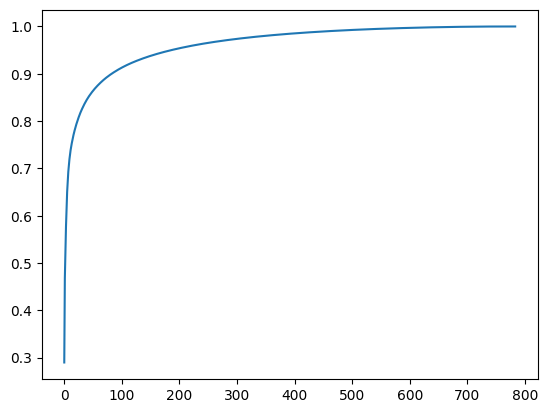

In [30]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))